#### Importing Packages

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#### Part A

In [9]:
data = pd.read_csv('HW04_data.csv')
#print(data.shape)
X = data.drop(columns=['Y'])
Y = data['Y']
#print(X.shape)
#print(Y.shape)
#print(X.head())
#print(Y.head())

#### Part B

In [10]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
#df1 = pd.DataFrame(x_train)
#df1.describe()

#df2 = pd.DataFrame(x_test)
#df2.describe()

#### Part C

In [11]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

#### Part D & E

Number of components needed to explain 95% variance: 14


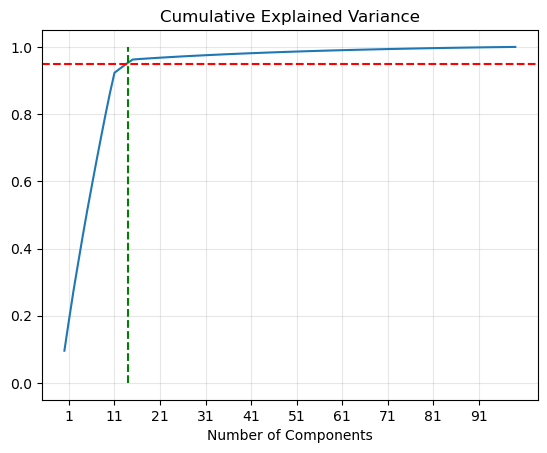

In [ ]:
pca = PCA(n_components=100)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)
explained_variance = pca.explained_variance_ratio_

sum=np.cumsum(explained_variance)
#print(sum)
x=np.argmax(sum >= 0.95)
print(f'Number of components needed to explain 95% variance: {x}')
plt.plot(sum)
plt.xlabel('Number of Components')
plt.axhline(y=0.95, color='r', linestyle='--')
plt.vlines(x, ymin=0, ymax=1, colors='g', linestyles='--')
plt.title('Cumulative Explained Variance')
plt.savefig('explained_variance.png')

#### Part F

In [13]:
pca2 = PCA(n_components=x)
x_train_pca2 = pca2.fit_transform(x_train)
x_test_pca2 = pca2.transform(x_test)
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train_pca2, y_train)

# Predict and evaluate
y_pred = model.predict(x_test_pca2)
from sklearn.metrics import mean_squared_error, r2_score
mse_test = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse_train = mean_squared_error(y_train, model.predict(x_train_pca2))
print("Train MSE:", mse_train)
print("Test MSE:", mse_test)
print("Test R^2:", r2)

Train MSE: 0.40678644372289513
Test MSE: 0.44144461785916045
Test R^2: 0.9922285232914021


#### Part G

    n_components  MSE_train   MSE_test        R2
0              1  46.973553  56.308304  0.008712
1              2  44.387087  54.309504  0.043900
2              3  43.286527  52.316595  0.078985
3              4  39.085378  47.522903  0.163376
4              5  35.871567  42.763396  0.247166
..           ...        ...        ...       ...
95            96   0.347110   0.483598  0.991486
96            97   0.346999   0.482968  0.991498
97            98   0.346963   0.483907  0.991481
98            99   0.346630   0.483268  0.991492
99           100   0.346462   0.482687  0.991502

[100 rows x 4 columns]


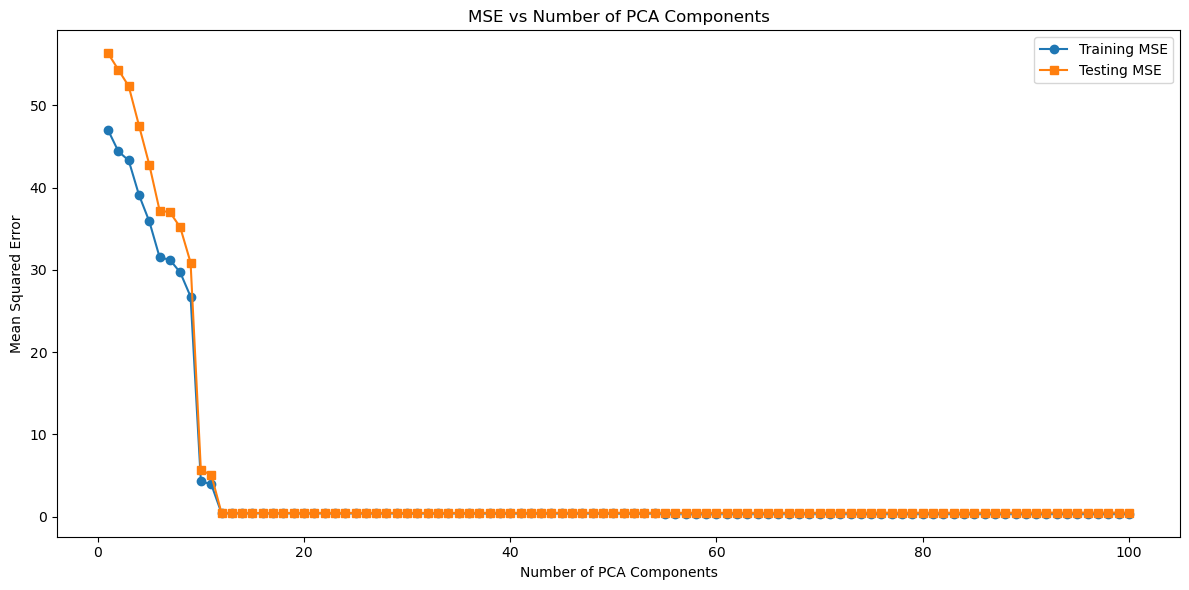

In [14]:
scores = []
for x in range(1, 101):
    pca = PCA(n_components=x)
    x_train_pca = pca.fit_transform(x_train)
    x_test_pca = pca.transform(x_test)
    model = LinearRegression()
    model.fit(x_train_pca, y_train)
    # Predict and evaluate
    y_pred = model.predict(x_test_pca)
    mse_train = mean_squared_error(y_train, model.predict(x_train_pca))
    mse_test = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    scores.append((x, mse_train, mse_test, r2))
data_frame = pd.DataFrame(scores, columns=['n_components', 'MSE_train', 'MSE_test', 'R2'])
print(data_frame)
plt.figure(figsize=(12, 6))
plt.plot(data_frame['n_components'], data_frame['MSE_train'], marker='o', label='Training MSE')
plt.plot(data_frame['n_components'], data_frame['MSE_test'], marker='s', label='Testing MSE')
plt.title('MSE vs Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.tight_layout()
plt.savefig('mse_vs_components.png')